# PA1 – Image Captioning Using CNN and LSTM

**Course:** DTSC 5525  
**Student:** Arya Ingale  

## Objective
The objective of this programming assignment is to implement an image
captioning system using a Convolutional Neural Network (CNN) for image
feature extraction and a Long Short-Term Memory (LSTM) network for
generating captions.

## 1. Import Required Libraries

This section imports the libraries needed for image processing,
data handling, CNN feature extraction, LSTM caption generation,
training, validation, and visualization.

In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from collections import Counter
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

import torchvision
from torchvision import transforms, models

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.14.0
Torchvision version: 0.29.0


In [3]:
%pip install torch torchvision torchaudio
%pip install requests certifi
%pip install openimages
%pip install torchinfo


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.14.0
Torchvision version: 0.29.0
CUDA available: False


In [5]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device being used:", device)

Device being used: mps


## 2. Download and Load the Image Caption Dataset

The Open Images Localized Narratives dataset is used for this assignment.
The annotation file contains image IDs and corresponding natural-language
captions that will be used to train the image captioning model.

In [6]:
import requests

url = (
    "https://storage.googleapis.com/localized-narratives/annotations/"
    "open_images_train_v6_captions.jsonl"
)

filename = "open_images_train_captions.jsonl"

if not os.path.exists(filename):
    print("Downloading caption dataset...")

    response = requests.get(url, stream=True)
    response.raise_for_status()

    with open(filename, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print("Download completed.")
else:
    print("Caption dataset already exists.")

print("File:", filename)

Caption dataset already exists.
File: open_images_train_captions.jsonl


In [7]:
with open(filename, "r", encoding="utf-8") as f:
    first_line = f.readline()

sample = json.loads(first_line)

print("Sample annotation:")
print(sample)

Sample annotation:
{'dataset_id': 'open_images', 'image_id': 'fc06c1b59dd8ca6e', 'annotator_id': 48, 'caption': 'We can see dolls,book and papers on bed and we can see poster on a wall,window and curtain,through this window we can see trees.'}


## 3. Prepare the Image-Caption Data

The annotation file contains image IDs and their corresponding captions.
A subset of the dataset is selected to make model training computationally
manageable. The selected samples are then divided into training and
validation sets.

In [8]:
# Number of image-caption samples to use
N = 5000

records = []

with open(filename, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= N:
            break

        try:
            record = json.loads(line)

            records.append({
                "image_id": record["image_id"],
                "caption": record["caption"]
            })

        except (json.JSONDecodeError, KeyError):
            continue

data = pd.DataFrame(records)

print("Total records:", len(data))
data.head()

Total records: 5000


,image_id,caption
0,fc06c1b59dd8ca6e,"We can see dolls,book and papers on bed and we..."
1,5833b3358fd949b5,In this picture I can see there is a airplane ...
2,67f1e4231b964a23,This looks like a black and white poster. I ca...
3,4839f5eac98771bf,In this image I can see on the left side it is...
4,64373c6a90e7b8dd,In this picture I can see group of people sitt...


In [9]:
# Reproducibility
np.random.seed(10)

# 95% training and 5% validation
data["train"] = np.random.choice(
    [True, False],
    size=len(data),
    p=[0.95, 0.05]
)

# Save the processed annotations
data.to_csv("data.csv", index=False)

print("Total samples:", len(data))
print("Training samples:", data["train"].sum())
print("Validation samples:", (~data["train"]).sum())

data.head()

Total samples: 5000
Training samples: 4762
Validation samples: 238


,image_id,caption,train
0,fc06c1b59dd8ca6e,"We can see dolls,book and papers on bed and we...",True
1,5833b3358fd949b5,In this picture I can see there is a airplane ...,True
2,67f1e4231b964a23,This looks like a black and white poster. I ca...,True
3,4839f5eac98771bf,In this image I can see on the left side it is...,True
4,64373c6a90e7b8dd,In this picture I can see group of people sitt...,True


## 4. Download Training and Validation Images

Using the image IDs obtained from the annotation dataset, the corresponding
Open Images are downloaded and stored separately for training and validation.

In [10]:
from openimages.download import _download_images_by_id

os.makedirs("train-images", exist_ok=True)
os.makedirs("val-images", exist_ok=True)

print("Open Images package imported successfully.")

Open Images package imported successfully.


In [11]:
train_image_ids = data[data["train"]]["image_id"].tolist()
val_image_ids = data[~data["train"]]["image_id"].tolist()

print("Training images to download:", len(train_image_ids))
print("Validation images to download:", len(val_image_ids))

Training images to download: 4762
Validation images to download: 238


In [12]:
# Find training images that are not already downloaded
missing_train_ids = [
    image_id
    for image_id in train_image_ids
    if not os.path.exists(
        os.path.join("train-images", f"{image_id}.jpg")
    )
]

print("Total required training images:", len(train_image_ids))
print("Training images already available:",
      len(train_image_ids) - len(missing_train_ids))
print("Missing training images:", len(missing_train_ids))

if missing_train_ids:
    print("Downloading missing training images...")

    _download_images_by_id(
        missing_train_ids,
        "train",
        "./train-images/"
    )

    print("Training image download completed.")
else:
    print("All required training images already exist.")

Total required training images: 4762
Training images already available: 1908
Missing training images: 2854


100%|██████████████████████████████████████████████████████████████████████████████| 2854/2854 [03:44<00:00, 12.71it/s]

Training image download completed.


In [13]:
# Find validation images that are not already downloaded
missing_val_ids = [
    image_id
    for image_id in val_image_ids
    if not os.path.exists(
        os.path.join("val-images", f"{image_id}.jpg")
    )
]

print("Total required validation images:", len(val_image_ids))
print("Validation images already available:",
      len(val_image_ids) - len(missing_val_ids))
print("Missing validation images:", len(missing_val_ids))

if missing_val_ids:
    print("Downloading missing validation images...")

    _download_images_by_id(
        missing_val_ids,
        "train",
        "./val-images/"
    )

    print("Validation image download completed.")
else:
    print("All required validation images already exist.")

Total required validation images: 238
Validation images already available: 92
Missing validation images: 146


100%|████████████████████████████████████████████████████████████████████████████████| 146/146 [00:10<00:00, 13.44it/s]

Validation image download completed.


In [14]:
# Verify that all required images were downloaded

missing_train = [
    image_id for image_id in train_image_ids
    if not os.path.exists(
        os.path.join("train-images", f"{image_id}.jpg")
    )
]

missing_val = [
    image_id for image_id in val_image_ids
    if not os.path.exists(
        os.path.join("val-images", f"{image_id}.jpg")
    )
]

print("Dataset verification")
print("--------------------")
print("Total samples:", len(data))
print("Required training images:", len(train_image_ids))
print("Required validation images:", len(val_image_ids))
print("Missing training images:", len(missing_train))
print("Missing validation images:", len(missing_val))

if len(missing_train) == 0 and len(missing_val) == 0:
    print("\n✓ All 5,000 image-caption samples are available.")
else:
    print("\nSome images are missing.")

Dataset verification
--------------------
Total samples: 5000
Required training images: 4762
Required validation images: 238
Missing training images: 0
Missing validation images: 0

✓ All 5,000 image-caption samples are available.


## 5. Caption Preprocessing and Vocabulary Creation

The image captions must be converted from text into numerical representations
before they can be used by the LSTM. A vocabulary is created to map each unique
word to an integer ID.

Special tokens are also included:

- `<pad>` for padding shorter captions
- `<unk>` for unknown words
- `<start>` to indicate the beginning of a caption
- `<end>` to indicate the end of a caption

In [15]:
from collections import Counter

# Use only training captions to build the vocabulary
training_captions = data[data["train"]]["caption"].tolist()

word_counter = Counter()

for caption in training_captions:
    tokens = caption.lower().split()
    word_counter.update(tokens)

print("Total unique words before filtering:", len(word_counter))

Total unique words before filtering: 4147


In [16]:
# Minimum word frequency
min_freq = 5

class Vocabulary:
    def __init__(self):
        self.itos = {
            0: "<pad>",
            1: "<unk>",
            2: "<start>",
            3: "<end>"
        }

        self.stoi = {
            "<pad>": 0,
            "<unk>": 1,
            "<start>": 2,
            "<end>": 3
        }

    def build_vocabulary(self, captions, min_freq=2):
        frequencies = Counter()

        for caption in captions:
            tokens = caption.lower().split()
            frequencies.update(tokens)

        idx = 4

        for word, freq in frequencies.items():
            if freq >= min_freq:
                self.stoi[word] = idx
                self.itos[idx] = word
                idx += 1

    def numericalize(self, text):
        tokens = text.lower().split()

        return [
            self.stoi.get(token, self.stoi["<unk>"])
            for token in tokens
        ]

In [17]:
vocab = Vocabulary()
vocab.build_vocabulary(training_captions, min_freq=min_freq)

print("Vocabulary size:", len(vocab.stoi))

print("\nSpecial token IDs:")
print("<pad>  :", vocab.stoi["<pad>"])
print("<unk>  :", vocab.stoi["<unk>"])
print("<start>:", vocab.stoi["<start>"])
print("<end>  :", vocab.stoi["<end>"])

Vocabulary size: 1266

Special token IDs:
<pad>  : 0
<unk>  : 1
<start>: 2
<end>  : 3


In [18]:
sample_caption = training_captions[0]

sample_tokens = vocab.numericalize(sample_caption)

print("Original caption:")
print(sample_caption)

print("\nNumericalized caption:")
print(sample_tokens)

Original caption:
We can see dolls,book and papers on bed and we can see poster on a wall,window and curtain,through this window we can see trees.

Numericalized caption:
[4, 5, 6, 1, 7, 8, 9, 10, 7, 4, 5, 6, 11, 9, 12, 1, 7, 1, 13, 14, 4, 5, 6, 15]


## 6. Create the Captioning Dataset Class

The custom dataset class loads each image and its corresponding caption.
The caption is converted into numerical token IDs using the vocabulary.

A `<start>` token is added at the beginning of each caption and an `<end>`
token is added at the end. Image transformations are also applied before
the data is passed to the CNN.

In [19]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

import torchvision
from torchvision import transforms, models

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

PyTorch version: 2.14.0
Torchvision version: 0.29.0


In [20]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device being used:", device)

Device being used: mps


In [21]:
class CaptioningDataset(Dataset):
    def __init__(self, root, df, vocab):
        self.root = root
        self.df = df.reset_index(drop=True)
        self.vocab = vocab

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]

        image_id = row["image_id"]
        caption = row["caption"]

        image_path = os.path.join(
            self.root,
            f"{image_id}.jpg"
        )

        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        numerical_caption = [
            self.vocab.stoi["<start>"]
        ]

        numerical_caption += self.vocab.numericalize(caption)

        numerical_caption.append(
            self.vocab.stoi["<end>"]
        )

        numerical_caption = torch.tensor(
            numerical_caption,
            dtype=torch.long
        )

        return image, numerical_caption, caption

In [22]:
train_df = data[data["train"]].reset_index(drop=True)
val_df = data[~data["train"]].reset_index(drop=True)

train_dataset = CaptioningDataset(
    root="train-images",
    df=train_df,
    vocab=vocab
)

val_dataset = CaptioningDataset(
    root="val-images",
    df=val_df,
    vocab=vocab
)

print("Training dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))

Training dataset size: 4762
Validation dataset size: 238


In [23]:
image, target, caption = train_dataset[0]

print("Image tensor shape:", image.shape)

print("\nCaption:")
print(caption)

print("\nToken IDs:")
print(target)

Image tensor shape: torch.Size([3, 224, 224])

Caption:
We can see dolls,book and papers on bed and we can see poster on a wall,window and curtain,through this window we can see trees.

Token IDs:
tensor([ 2,  4,  5,  6,  1,  7,  8,  9, 10,  7,  4,  5,  6, 11,  9, 12,  1,  7,
         1, 13, 14,  4,  5,  6, 15,  3])


## 7. Create DataLoaders and Display a Sample

Because captions have different lengths, shorter captions must be padded
within each batch. A custom `collate_fn` function is used to create batches
with equal-length caption tensors.

This section also displays a sample image with its corresponding caption.

In [24]:
def collate_fn(batch):
    # Sort by caption length in descending order
    batch.sort(key=lambda x: len(x[1]), reverse=True)

    images, captions, original_captions = zip(*batch)

    # Stack image tensors
    images = torch.stack(images, dim=0)

    # Length of each caption
    lengths = [len(caption) for caption in captions]

    # Create padded caption tensor
    padded_captions = torch.zeros(
        len(captions),
        max(lengths),
        dtype=torch.long
    )

    for i, caption in enumerate(captions):
        end = lengths[i]
        padded_captions[i, :end] = caption[:end]

    return (
        images,
        padded_captions,
        torch.tensor(lengths, dtype=torch.long)
    )

In [25]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 149
Validation batches: 8


In [26]:
images, captions_batch, lengths = next(iter(train_loader))

print("Images shape:", images.shape)
print("Captions shape:", captions_batch.shape)
print("Lengths shape:", lengths.shape)
print("First 5 caption lengths:", lengths[:5])

Images shape: torch.Size([32, 3, 224, 224])
Captions shape: torch.Size([32, 76])
Lengths shape: torch.Size([32])
First 5 caption lengths: tensor([76, 62, 59, 59, 53])


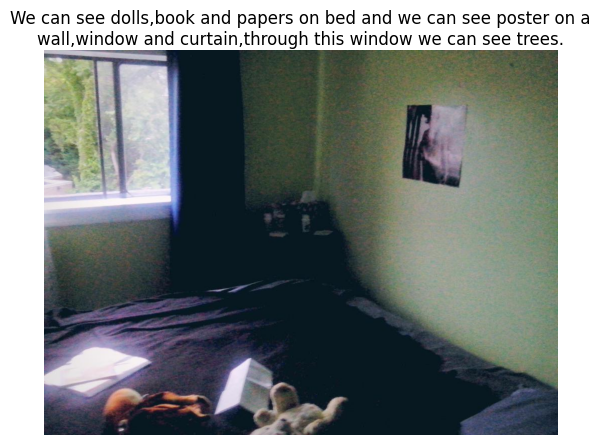

Caption:
We can see dolls,book and papers on bed and we can see poster on a wall,window and curtain,through this window we can see trees.


In [27]:
# Get an untransformed image path and caption
sample_row = train_df.iloc[0]

sample_path = os.path.join(
    "train-images",
    f"{sample_row['image_id']}.jpg"
)

sample_image = Image.open(sample_path).convert("RGB")
sample_caption = sample_row["caption"]

plt.figure(figsize=(7, 5))
plt.imshow(sample_image)
plt.axis("off")
plt.title(sample_caption, wrap=True)
plt.show()

print("Caption:")
print(sample_caption)

## 8. CNN Encoder Using Pretrained ResNet-152

A pretrained ResNet-152 convolutional neural network is used as the image
encoder. The final fully connected classification layer is removed so that
the CNN can be used as a feature extractor.

The extracted image features are passed through a linear layer and batch
normalization to produce a 256-dimensional feature vector. These features
will later be provided to the LSTM decoder for caption generation.

In [28]:
import requests
import os

weights_url = "https://download.pytorch.org/models/resnet152-f82ba261.pth"
weights_file = "resnet152-f82ba261.pth"

if not os.path.exists(weights_file):
    print("Downloading ResNet-152 weights...")

    response = requests.get(weights_url, stream=True)
    response.raise_for_status()

    with open(weights_file, "wb") as f:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                f.write(chunk)

    print("Download completed.")
else:
    print("ResNet-152 weights already exist.")

ResNet-152 weights already exist.


In [29]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()

        # Create ResNet-152 architecture without automatic download
        resnet = models.resnet152(weights=None)

        # Load pretrained weights manually
        state_dict = torch.load(
            "resnet152-f82ba261.pth",
            map_location="cpu"
        )

        resnet.load_state_dict(state_dict)

        # Remove final fully connected layer
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)

        # Freeze pretrained CNN parameters
        for param in self.resnet.parameters():
            param.requires_grad = False

        self.linear = nn.Linear(
            resnet.fc.in_features,
            embed_size
        )

        self.bn = nn.BatchNorm1d(
            embed_size,
            momentum=0.01
        )

    def forward(self, images):
        with torch.no_grad():
            features = self.resnet(images)

        features = features.reshape(
            features.size(0),
            -1
        )

        features = self.linear(features)
        features = self.bn(features)

        return features

In [30]:
embed_size = 256

encoder = EncoderCNN(embed_size).to(device)

print("Encoder created successfully.")

Encoder created successfully.


In [31]:
encoder.eval()

test_images = images[:2].to(device)

with torch.no_grad():
    test_features = encoder(test_images)

print("Input image batch shape:", test_images.shape)
print("Encoder output shape:", test_features.shape)

Input image batch shape: torch.Size([2, 3, 224, 224])
Encoder output shape: torch.Size([2, 256])


## 9. Encoder Model Summary and Parameter Count

This section displays the architecture of the CNN encoder and reports the
total and trainable number of model parameters.

In [32]:
from torchinfo import summary

summary(
    encoder,
    input_size=(2, 3, 224, 224),
    device=str(device)
)

Layer (type:depth-idx)                        Output Shape              Param #
EncoderCNN                                    [2, 256]                  --
├─Sequential: 1-1                             [2, 2048, 1, 1]           --
│    └─Conv2d: 2-1                            [2, 64, 112, 112]         (9,408)
│    └─BatchNorm2d: 2-2                       [2, 64, 112, 112]         (128)
│    └─ReLU: 2-3                              [2, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [2, 64, 56, 56]           --
│    └─Sequential: 2-5                        [2, 256, 56, 56]          --
│    │    └─Bottleneck: 3-1                   [2, 256, 56, 56]          (75,008)
│    │    └─Bottleneck: 3-2                   [2, 256, 56, 56]          (70,400)
│    │    └─Bottleneck: 3-3                   [2, 256, 56, 56]          (70,400)
│    └─Sequential: 2-6                        [2, 512, 28, 28]          --
│    │    └─Bottleneck: 3-4                   [2, 512, 28, 28]       

In [33]:
total_params = sum(
    p.numel() for p in encoder.parameters()
)

trainable_params = sum(
    p.numel() for p in encoder.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters:    {frozen_params:,}")

Total parameters:     58,668,864
Trainable parameters: 525,056
Frozen parameters:    58,143,808


## 10. LSTM Decoder

The LSTM decoder generates captions from the image features extracted by
the CNN encoder. Caption words are first converted into embedding vectors.

The image feature vector is combined with the caption embeddings and passed
through an LSTM network. A fully connected layer then maps the LSTM outputs
to the vocabulary to predict the next word in the caption.

In [34]:
class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(DecoderRNN, self).__init__()

        self.embed = nn.Embedding(
            vocab_size,
            embed_size
        )

        self.lstm = nn.LSTM(
            embed_size,
            hidden_size,
            num_layers,
            batch_first=True
        )

        self.linear = nn.Linear(
            hidden_size,
            vocab_size
        )

    def forward(self, features, captions, lengths):

        # Convert caption token IDs into embeddings
        embeddings = self.embed(captions)

        # Add CNN image features at the beginning
        embeddings = torch.cat(
            (features.unsqueeze(1), embeddings),
            dim=1
        )

        # IMPORTANT:
        # Do not add 1 to lengths here.
        # The supplied lengths already represent the number
        # of next-word predictions required.

        packed = pack_padded_sequence(
            embeddings,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=True
        )

        hiddens, _ = self.lstm(packed)

        outputs = self.linear(hiddens.data)

        return outputs

In [35]:
hidden_size = 512
vocab_size = len(vocab.stoi)
num_layers = 1

decoder = DecoderRNN(
    embed_size=embed_size,
    hidden_size=hidden_size,
    vocab_size=vocab_size,
    num_layers=num_layers
).to(device)

print("Decoder recreated successfully.")

Decoder recreated successfully.


In [36]:
decoder_params = sum(
    p.numel() for p in decoder.parameters()
)

print(f"Decoder parameters: {decoder_params:,}")

Decoder parameters: 2,550,514


## 11. Loss Function, Optimizer, Training, and Validation

The model is trained using CrossEntropyLoss because caption generation is
treated as a multi-class word prediction problem.

The AdamW optimizer is used to update the trainable parameters of the
decoder and the trainable layers of the CNN encoder.

In [37]:
criterion = nn.CrossEntropyLoss(
    ignore_index=vocab.stoi["<pad>"]
)

params = (
    list(decoder.parameters()) +
    list(encoder.linear.parameters()) +
    list(encoder.bn.parameters())
)

optimizer = torch.optim.AdamW(
    params,
    lr=1e-3
)

print("Optimizer recreated successfully.")

Optimizer recreated successfully.


In [38]:
def train_one_epoch(
    train_loader,
    encoder,
    decoder,
    optimizer,
    criterion
):
    encoder.train()
    decoder.train()

    total_loss = 0

    for images, captions, lengths in train_loader:

        images = images.to(device)
        captions = captions.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()

        # CNN image features
        features = encoder(images)

        # Remove final token from decoder input
        input_captions = captions[:, :-1]

        # Target excludes the <start> token
        target_captions = captions[:, 1:]

        # Actual target lengths after removing <start>
        target_lengths = lengths - 1

        # Decoder prediction
        outputs = decoder(
            features,
            input_captions,
            target_lengths
        )

        # Pack targets so padding is ignored
        targets = pack_padded_sequence(
            target_captions,
            target_lengths.cpu(),
            batch_first=True,
            enforce_sorted=True
        ).data

        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [39]:
@torch.no_grad()
def validate_one_epoch(
    val_loader,
    encoder,
    decoder,
    criterion
):
    encoder.eval()
    decoder.eval()

    total_loss = 0

    for images, captions, lengths in val_loader:

        images = images.to(device)
        captions = captions.to(device)
        lengths = lengths.to(device)

        features = encoder(images)

        input_captions = captions[:, :-1]
        target_captions = captions[:, 1:]

        target_lengths = lengths - 1

        outputs = decoder(
            features,
            input_captions,
            target_lengths
        )

        targets = pack_padded_sequence(
            target_captions,
            target_lengths.cpu(),
            batch_first=True,
            enforce_sorted=True
        ).data

        loss = criterion(outputs, targets)

        total_loss += loss.item()

    return total_loss / len(val_loader)

## 12. Test the Model on a Single Batch

Before training for multiple epochs, a single batch is passed through the
CNN encoder and LSTM decoder to verify that the model dimensions, targets,
and loss calculation are working correctly.

In [40]:
# Get one training batch
test_images, test_captions, test_lengths = next(iter(train_loader))

test_images = test_images.to(device)
test_captions = test_captions.to(device)
test_lengths = test_lengths.to(device)

# Set models to training mode
encoder.train()
decoder.train()

# Extract image features
test_features = encoder(test_images)

# Prepare decoder inputs and targets
input_captions = test_captions[:, :-1]
target_captions = test_captions[:, 1:]
target_lengths = test_lengths - 1

# Forward pass through decoder
test_outputs = decoder(
    test_features,
    input_captions,
    target_lengths
)

# Pack targets
test_targets = pack_padded_sequence(
    target_captions,
    target_lengths.cpu(),
    batch_first=True,
    enforce_sorted=True
).data

# Calculate loss
test_loss = criterion(test_outputs, test_targets)

print("Image batch shape:", test_images.shape)
print("Caption batch shape:", test_captions.shape)
print("Model output shape:", test_outputs.shape)
print("Target shape:", test_targets.shape)
print("Single-batch loss:", test_loss.item())

Image batch shape: torch.Size([32, 3, 224, 224])
Caption batch shape: torch.Size([32, 85])
Model output shape: torch.Size([1070, 1266])
Target shape: torch.Size([1070])
Single-batch loss: 7.142795562744141


## 13. Train the CNN-LSTM Image Captioning Model

The model is trained for multiple epochs using the training dataset and
evaluated on the validation dataset after each epoch.

Training and validation losses are recorded so their behavior can be
visualized after training.

In [43]:
num_epochs = 10

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    train_loss = train_one_epoch(
       train_loader,
       encoder,
       decoder,
       optimizer,
       criterion
)

    val_loss = validate_one_epoch(
      val_loader,
      encoder,
      decoder,
      criterion
)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch + 1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Validation Loss: {val_loss:.4f}"
    )

    # Reduce learning rate after epoch 5
    if epoch == 4:
        optimizer = torch.optim.AdamW(params, lr=1e-4)
        print("Learning rate reduced to 1e-4")

Epoch [1/10] Train Loss: 3.9771 | Validation Loss: 3.4642
Epoch [2/10] Train Loss: 3.2972 | Validation Loss: 3.2267
Epoch [3/10] Train Loss: 3.0865 | Validation Loss: 3.1096
Epoch [4/10] Train Loss: 2.9389 | Validation Loss: 3.0355
Epoch [5/10] Train Loss: 2.8224 | Validation Loss: 2.9851
Learning rate reduced to 1e-4
Epoch [6/10] Train Loss: 2.6832 | Validation Loss: 2.9559
Epoch [7/10] Train Loss: 2.6562 | Validation Loss: 2.9502
Epoch [8/10] Train Loss: 2.6373 | Validation Loss: 2.9463
Epoch [9/10] Train Loss: 2.6219 | Validation Loss: 2.9431
Epoch [10/10] Train Loss: 2.6052 | Validation Loss: 2.9403


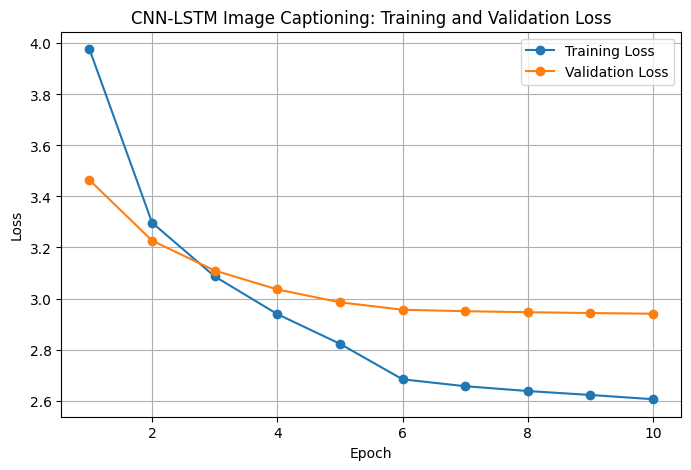

Loss curve saved to results/loss_curve.png


In [44]:
import os
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, num_epochs + 1),
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN-LSTM Image Captioning: Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.savefig(
    "results/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Loss curve saved to results/loss_curve.png")

In [46]:
print("Training Summary")
print("----------------")
print("Total samples:", len(data))
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Epochs:", num_epochs)
print("Vocabulary size:", len(vocab.itos))

print()
print(f"Initial training loss: {train_losses[0]:.4f}")
print(f"Final training loss: {train_losses[-1]:.4f}")
print(f"Initial validation loss: {val_losses[0]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")

Training Summary
----------------
Total samples: 5000
Training samples: 4762
Validation samples: 238
Epochs: 10
Vocabulary size: 1266

Initial training loss: 3.9771
Final training loss: 2.6052
Initial validation loss: 3.4642
Final validation loss: 2.9403


## 14. Generate Captions Using the Trained Model

After training, the CNN encoder extracts features from a new validation
image. The LSTM decoder then generates one word at a time until the
`<end>` token is predicted or the maximum caption length is reached.

The predicted caption is compared with the original ground-truth caption.

In [47]:
@torch.no_grad()
def generate_caption(image_path, encoder, decoder, vocab, max_length=50):

    encoder.eval()
    decoder.eval()

    # Image preprocessing
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    # Load image
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    # Extract CNN feature
    feature = encoder(image_tensor)

    # Use CNN feature as first LSTM input
    inputs = feature.unsqueeze(1)

    states = None
    predicted_words = []

    for _ in range(max_length):

        # Pass current input through LSTM
        hidden, states = decoder.lstm(inputs, states)

        # Predict next word
        output = decoder.linear(hidden.squeeze(1))

        predicted_id = output.argmax(dim=1).item()

        predicted_word = vocab.itos[predicted_id]

        # Stop when <end> is generated
        if predicted_word == "<end>":
            break

        # Ignore special tokens in displayed caption
        if predicted_word not in ["<start>", "<pad>"]:
            predicted_words.append(predicted_word)

        # Convert predicted word back to embedding
        predicted_tensor = torch.tensor(
            [predicted_id],
            device=device
        )

        inputs = decoder.embed(predicted_tensor).unsqueeze(1)

    predicted_caption = " ".join(predicted_words)

    return image, predicted_caption

Reference Caption:
In this image we can see an advertisement and the picture of woman working at the desktop.

Generated Caption:
in image can the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is


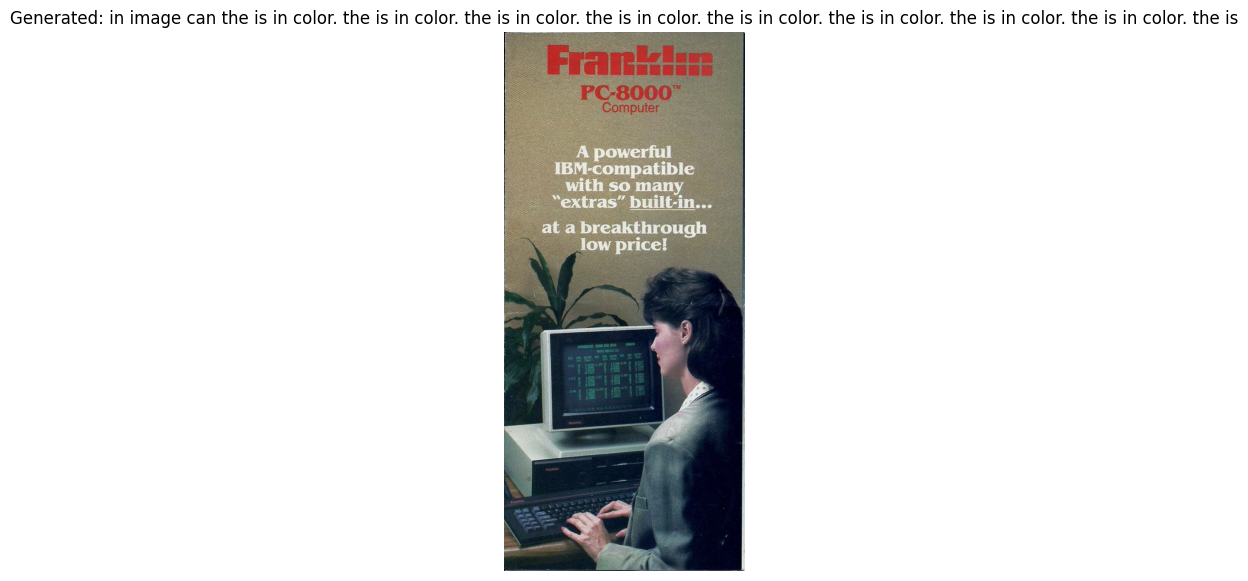

In [48]:
# Select one validation image
sample_row = data[data["train"] == False].iloc[0]

image_id = sample_row["image_id"]
reference_caption = sample_row["caption"]

image_path = os.path.join(
    "val-images",
    f"{image_id}.jpg"
)

# Generate caption
image, predicted_caption = generate_caption(
    image_path,
    encoder,
    decoder,
    vocab
)

print("Reference Caption:")
print(reference_caption)

print("\nGenerated Caption:")
print(predicted_caption)

# Display image
plt.figure(figsize=(7, 7))
plt.imshow(image)
plt.axis("off")
plt.title(f"Generated: {predicted_caption}")
plt.show()

In [49]:
# Generate captions for 5 validation images

validation_samples = data[data["train"] == False].head(5)

for i, (_, row) in enumerate(validation_samples.iterrows(), start=1):

    image_id = row["image_id"]
    reference_caption = row["caption"]

    image_path = os.path.join(
        "val-images",
        f"{image_id}.jpg"
    )

    image, predicted_caption = generate_caption(
        image_path,
        encoder,
        decoder,
        vocab
    )

    print(f"\nExample {i}")
    print("-" * 50)
    print("Reference:", reference_caption)
    print("Generated:", predicted_caption)


Example 1
--------------------------------------------------
Reference: In this image we can see an advertisement and the picture of woman working at the desktop.
Generated: in image can the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is

Example 2
--------------------------------------------------
Reference: This is a person standing. This looks like a fire. There are group of people standing. These are the buildings with lighting.
Generated: in in i see is and color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in color. the is in

Example 3
--------------------------------------------------
Reference: In this picture we can see food.
Generated: in image can the there a <unk> the is

Example 4
--------------------------------------------------
Reference: In this image I see a roo

In [50]:
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 16.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [nltk]━━━━━━━━━━━━━ 2/3 [nltk]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [51]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

smoothing = SmoothingFunction().method1

bleu1_scores = []
bleu2_scores = []
bleu3_scores = []
bleu4_scores = []

validation_data = data[data["train"] == False]

for _, row in validation_data.iterrows():

    image_id = row["image_id"]
    reference_caption = row["caption"]

    image_path = os.path.join(
        "val-images",
        f"{image_id}.jpg"
    )

    _, predicted_caption = generate_caption(
        image_path,
        encoder,
        decoder,
        vocab
    )

    reference = reference_caption.lower().split()
    candidate = predicted_caption.lower().split()

    # Skip empty predictions
    if len(candidate) == 0:
        continue

    references = [reference]

    bleu1_scores.append(
        sentence_bleu(
            references,
            candidate,
            weights=(1.0, 0, 0, 0),
            smoothing_function=smoothing
        )
    )

    bleu2_scores.append(
        sentence_bleu(
            references,
            candidate,
            weights=(0.5, 0.5, 0, 0),
            smoothing_function=smoothing
        )
    )

    bleu3_scores.append(
        sentence_bleu(
            references,
            candidate,
            weights=(1/3, 1/3, 1/3, 0),
            smoothing_function=smoothing
        )
    )

    bleu4_scores.append(
        sentence_bleu(
            references,
            candidate,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothing
        )
    )

print("BLEU Evaluation")
print("----------------")
print("Evaluated captions:", len(bleu1_scores))
print(f"BLEU-1: {np.mean(bleu1_scores):.4f}")
print(f"BLEU-2: {np.mean(bleu2_scores):.4f}")
print(f"BLEU-3: {np.mean(bleu3_scores):.4f}")
print(f"BLEU-4: {np.mean(bleu4_scores):.4f}")

BLEU Evaluation
----------------
Evaluated captions: 238
BLEU-1: 0.1879
BLEU-2: 0.0258
BLEU-3: 0.0116
BLEU-4: 0.0081


In [52]:
%pip install rouge-score

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24987 sha256=1a6b8b9d8694c493777c08fa1e92aa3717169e4910982e70fef29fb08a5fcc98
  Stored in directory: /Users/aryayogirajingale/Library/Caches/pip/wheels/fa/77/62/e75e60437a9821bbc6523332a7453f56b0720535477de63f75
Successfully built rouge-score
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [rouge-score]

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [53]:
from rouge_score import rouge_scorer

rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

rouge_l_scores = []

validation_data = data[data["train"] == False]

for _, row in validation_data.iterrows():

    image_id = row["image_id"]
    reference_caption = row["caption"]

    image_path = os.path.join(
        "val-images",
        f"{image_id}.jpg"
    )

    _, predicted_caption = generate_caption(
        image_path,
        encoder,
        decoder,
        vocab
    )

    if predicted_caption.strip() == "":
        continue

    score = rouge.score(
        reference_caption,
        predicted_caption
    )

    rouge_l_scores.append(
        score["rougeL"].fmeasure
    )

print("ROUGE Evaluation")
print("----------------")
print("Evaluated captions:", len(rouge_l_scores))
print(f"ROUGE-L: {np.mean(rouge_l_scores):.4f}")

2026-09-24  08:43:40 INFO Using default tokenizer.


ROUGE Evaluation
----------------
Evaluated captions: 238
ROUGE-L: 0.2464


In [55]:
print("=" * 45)
print("CNN-LSTM IMAGE CAPTIONING RESULTS")
print("=" * 45)

print("\nDataset")
print("-------")
print("Total samples:", len(data))
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

print("\nModel")
print("-----")
print("Encoder: ResNet-152")
print("Decoder: LSTM")
print("Embedding size: 256")
print("Hidden size: 512")
print("Vocabulary size:", len(vocab.itos))
print("Epochs:", num_epochs)

print("\nTraining")
print("--------")
print(f"Initial Train Loss: {train_losses[0]:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Initial Validation Loss: {val_losses[0]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")

print("\nCaption Evaluation")
print("------------------")
print(f"BLEU-1: {np.mean(bleu1_scores):.4f}")
print(f"BLEU-2: {np.mean(bleu2_scores):.4f}")
print(f"BLEU-3: {np.mean(bleu3_scores):.4f}")
print(f"BLEU-4: {np.mean(bleu4_scores):.4f}")
print(f"ROUGE-L: {np.mean(rouge_l_scores):.4f}")

print("=" * 45)

CNN-LSTM IMAGE CAPTIONING RESULTS

Dataset
-------
Total samples: 5000
Training samples: 4762
Validation samples: 238

Model
-----
Encoder: ResNet-152
Decoder: LSTM
Embedding size: 256
Hidden size: 512
Vocabulary size: 1266
Epochs: 10

Training
--------
Initial Train Loss: 3.9771
Final Train Loss: 2.6052
Initial Validation Loss: 3.4642
Final Validation Loss: 2.9403

Caption Evaluation
------------------
BLEU-1: 0.1879
BLEU-2: 0.0258
BLEU-3: 0.0116
BLEU-4: 0.0081
ROUGE-L: 0.2464


In [56]:
results_summary = f"""
CNN-LSTM Image Captioning Results
=================================

Dataset
-------
Total Samples: {len(data)}
Training Samples: {len(train_dataset)}
Validation Samples: {len(val_dataset)}

Model
-----
Encoder: ResNet-152
Decoder: LSTM
Embedding Size: 256
Hidden Size: 512
Vocabulary Size: {len(vocab.itos)}
Epochs: {num_epochs}

Training Results
----------------
Initial Training Loss: {train_losses[0]:.4f}
Final Training Loss: {train_losses[-1]:.4f}
Initial Validation Loss: {val_losses[0]:.4f}
Final Validation Loss: {val_losses[-1]:.4f}

Caption Evaluation
------------------
BLEU-1: {np.mean(bleu1_scores):.4f}
BLEU-2: {np.mean(bleu2_scores):.4f}
BLEU-3: {np.mean(bleu3_scores):.4f}
BLEU-4: {np.mean(bleu4_scores):.4f}
ROUGE-L: {np.mean(rouge_l_scores):.4f}
"""

with open("results/evaluation_results.txt", "w") as f:
    f.write(results_summary)

print("Evaluation results saved to results/evaluation_results.txt")

Evaluation results saved to results/evaluation_results.txt


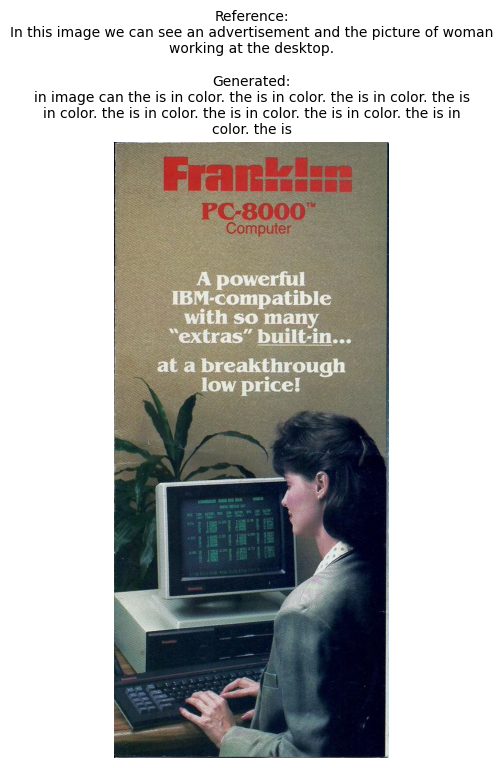

Saved: results/prediction_01.png


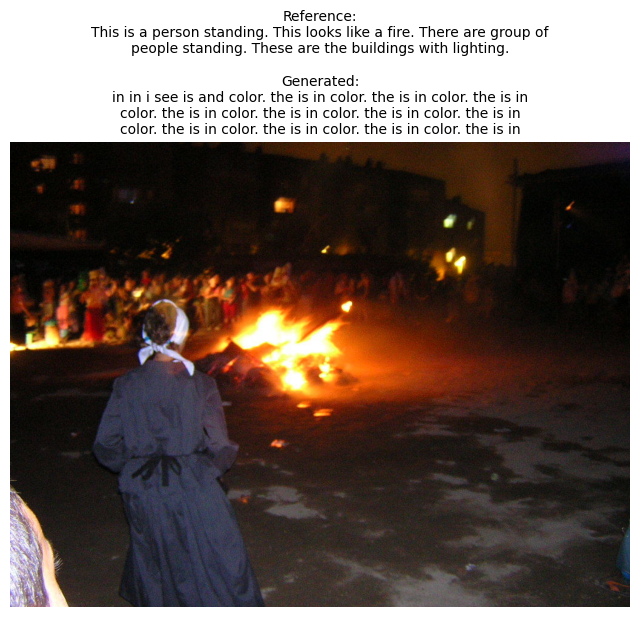

Saved: results/prediction_02.png


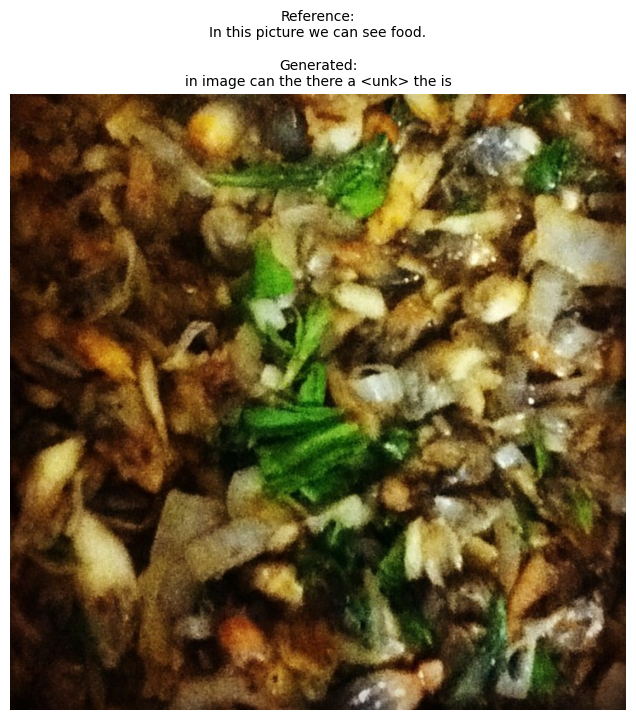

Saved: results/prediction_03.png


In [57]:
import os
import textwrap

os.makedirs("results", exist_ok=True)

validation_examples = data[data["train"] == False].head(3)

for example_num, (_, row) in enumerate(
    validation_examples.iterrows(),
    start=1
):
    image_id = row["image_id"]
    reference_caption = row["caption"]

    image_path = os.path.join(
        "val-images",
        f"{image_id}.jpg"
    )

    image, predicted_caption = generate_caption(
        image_path,
        encoder,
        decoder,
        vocab
    )

    # Wrap long captions so they fit in the figure
    reference_wrapped = "\n".join(
        textwrap.wrap(reference_caption, width=70)
    )

    prediction_wrapped = "\n".join(
        textwrap.wrap(predicted_caption, width=70)
    )

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Reference:\n{reference_wrapped}\n\n"
        f"Generated:\n{prediction_wrapped}",
        fontsize=10
    )

    output_path = (
        f"results/prediction_{example_num:02d}.png"
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved: {output_path}")

In [43]:
torch.save(
    encoder.state_dict(),
    "encoder_model.pth"
)

torch.save(
    decoder.state_dict(),
    "decoder_model.pth"
)

print("Trained models saved successfully.")

Trained models saved successfully.
